# InSIGHT — Ensemble Detector Balanced Test 성능 리포트

**모델:** `haywoodsloan/ai-image-detector-deploy (w=0.6)` + `Organika/sdxl-detector (w=0.4)`  
**전략:** 소프트 보팅 (가중 평균, threshold=0.5)  
**작성자:** woochul  
**실험 일시:** 2026-05-11  
**데이터셋:** AI 생성 이미지 100장 + 실제 이미지 100장 **(균형, 50:50)**  

---

### 왜 Balanced Test?

기존 350장 테스트는 **AI 101장 (29%) / Real 249장 (71%)** 으로 Real 쪽으로 크게 치우쳐 있었습니다.  
클래스 불균형 데이터에서는 **Accuracy가 과대평가**되고 진짜 판별 능력이 가려질 수 있습니다.  
Balanced Test(100 + 100)는 클래스 편향 없이 **모델의 실제 구별 능력**을 측정합니다.

### 평가 목표치
| 지표 | 목표 | 방향 |
|---|---|---|
| Accuracy | 70% 이상 | ↑ |
| Precision | 75% 이상 | ↑ |
| Recall ★ | 75% 이상 (핵심) | ↑ |
| F1 Score | 70% 이상 | ↑ |
| FPR | 20% 이하 | ↓ |
| Avg Inference Time | 3초 이하 | ↓ |

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family']       = 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

COLOR_PASS      = '#2ecc71'
COLOR_FAIL      = '#e74c3c'
COLOR_BALANCED  = '#E67E22'   # 주황 — 균형 테스트
COLOR_IMBAL     = '#9B59B6'   # 보라 — 기존 앙상블(불균형)
COLOR_DEPLOY    = '#3498db'   # 파랑 — deploy 단독
COLOR_SDXL      = '#1ABC9C'   # 청록 — sdxl 단독
COLOR_TARGET    = '#f39c12'
COLOR_AI        = '#e74c3c'
COLOR_REAL      = '#3498db'

BENCH_DIR = os.path.dirname(os.path.abspath('__file__'))

TARGET = {
    'accuracy' : 70.0,
    'precision': 75.0,
    'recall'   : 75.0,
    'f1'       : 70.0,
    'fpr'      : 20.0,
    'avg_time' :  3.0,
}

# ── 균형 테스트 결과 로드 (최신 CSV 자동 선택) ──
csv_files = sorted(glob.glob(os.path.join(BENCH_DIR, 'ensemble_balanced_results_*.csv')))
assert csv_files, 'ensemble_balanced_results_*.csv 파일이 없습니다. 벤치마크를 먼저 실행하세요.'
csv_path = csv_files[-1]
print(f'로드: {os.path.basename(csv_path)}')

df = pd.read_csv(csv_path)
m  = df.iloc[0].to_dict()
for k in ['accuracy','precision','recall','f1','fpr','avg_time','tp','fp','fn','tn']:
    m[k] = float(m[k])
tp, fp, fn, tn = int(m['tp']), int(m['fp']), int(m['fn']), int(m['tn'])
total = tp + fp + fn + tn

# ── 기존 앙상블(350장, 불균형) 참고값 ──
IMBAL = {
    'label': '앙상블 350장(불균형)',
    'accuracy':89.97,'precision':77.97,'recall':91.09,
    'f1':84.02,'fpr':10.48,'avg_time':0.694,
    'tp':92,'fp':26,'fn':9,'tn':222,
}

# ── 단일 모델 기준값 (불균형 350장 기준, 참고) ──
DEPLOY = {
    'label': 'deploy (단독, 350장)',
    'accuracy':88.25,'precision':75.86,'recall':87.13,
    'f1':81.11,'fpr':11.29,'avg_time':0.828,
    'tp':88,'fp':28,'fn':13,'tn':220,
}
SDXL = {
    'label': 'sdxl (단독, 350장)',
    'accuracy':77.08,'precision':59.13,'recall':67.33,
    'f1':62.96,'fpr':18.95,'avg_time':0.449,
    'tp':68,'fp':47,'fn':33,'tn':201,
}

print(f'\n[균형 테스트 결과] AI 100 + Real 100 = {total}장 처리')
print(f'TP={tp}  FP={fp}  FN={fn}  TN={tn}')
print(f'Accuracy={m["accuracy"]:.2f}%  Precision={m["precision"]:.2f}%  Recall={m["recall"]:.2f}%')
print(f'F1={m["f1"]:.2f}%  FPR={m["fpr"]:.2f}%  Avg Time={m["avg_time"]:.3f}s')

로드: ensemble_balanced_results_20260511_105508.csv

[균형 테스트 결과] AI 100 + Real 100 = 199장 처리
TP=91  FP=13  FN=9  TN=86
Accuracy=88.94%  Precision=87.50%  Recall=91.00%
F1=89.22%  FPR=13.13%  Avg Time=0.734s


---
## 1. 핵심 지표 요약

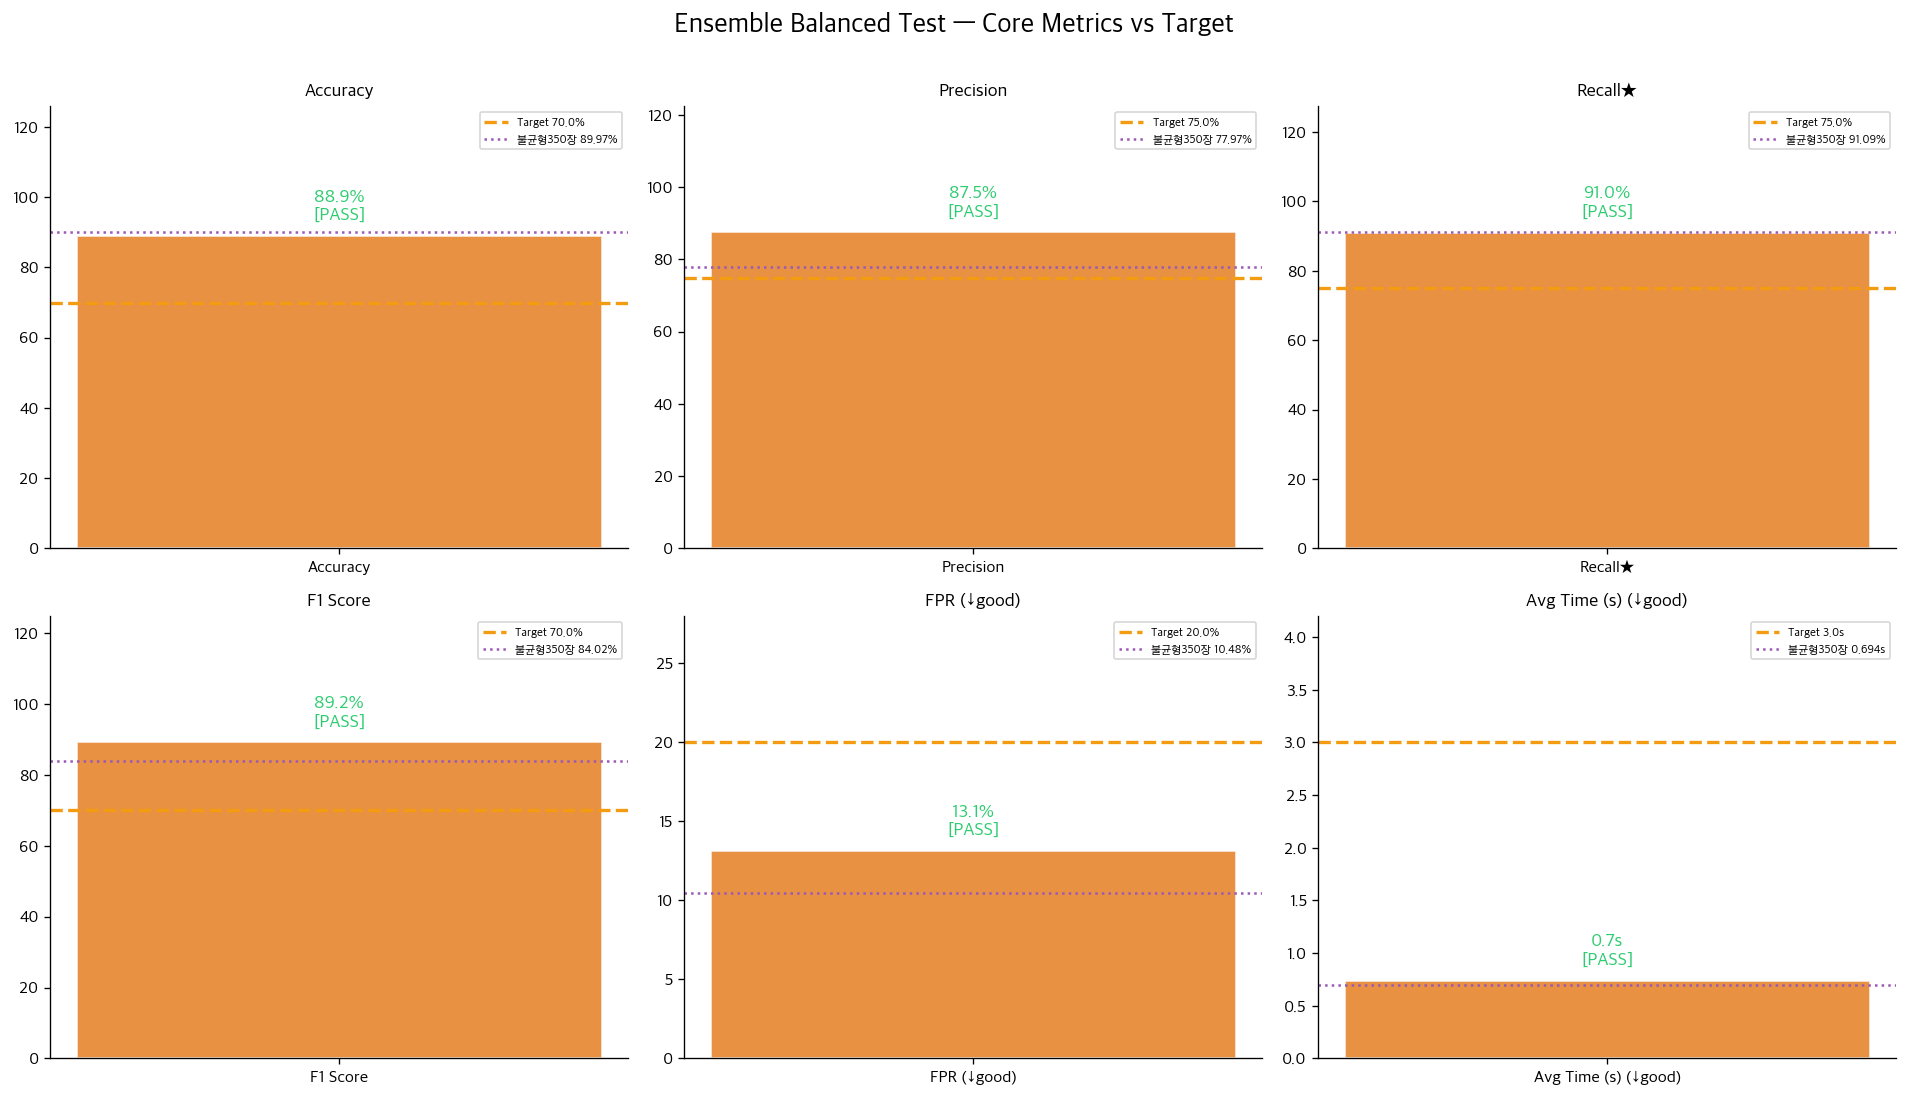

In [2]:
metrics       = ['accuracy','precision','recall','f1','fpr','avg_time']
metric_labels = ['Accuracy','Precision','Recall★','F1 Score','FPR (↓good)','Avg Time (s) (↓good)']
lower_better  = [False, False, False, False, True, True]

vals    = [m[k] for k in metrics]
targets = [TARGET[k] for k in metrics]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Ensemble Balanced Test — Core Metrics vs Target', fontsize=16, fontweight='bold', y=1.01)

for ax, metric, label, val, target, lower in zip(
        axes.flat, metrics, metric_labels, vals, targets, lower_better):
    ok    = (val <= target) if lower else (val >= target)
    color = COLOR_PASS if ok else COLOR_FAIL
    unit  = 's' if 'time' in metric else '%'
    ax.bar([label], [val], color=COLOR_BALANCED, alpha=0.85, edgecolor='white', width=0.5)
    ax.axhline(target, color=COLOR_TARGET, linestyle='--', linewidth=2,
               label=f'Target {target}{unit}')
    imbal_val = IMBAL[metric]
    ax.axhline(imbal_val, color=COLOR_IMBAL, linestyle=':', linewidth=1.5,
               label=f'불균형350장 {imbal_val}{unit}')
    ax.set_ylim(0, max(val, target, imbal_val) * 1.4)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=7)
    badge = 'PASS' if ok else 'FAIL'
    ax.text(0, val + max(val, target)*0.05,
            f'{val:.1f}{unit}\n[{badge}]', ha='center', fontsize=11,
            fontweight='bold', color=COLOR_PASS if ok else COLOR_FAIL)

plt.tight_layout()
os.makedirs(os.path.join(BENCH_DIR, 'charts'), exist_ok=True)
plt.savefig(os.path.join(BENCH_DIR,'charts','ensemble_balanced_core_metrics.png'), bbox_inches='tight', dpi=150)
plt.show()

---
## 2. 목표치 달성 현황표

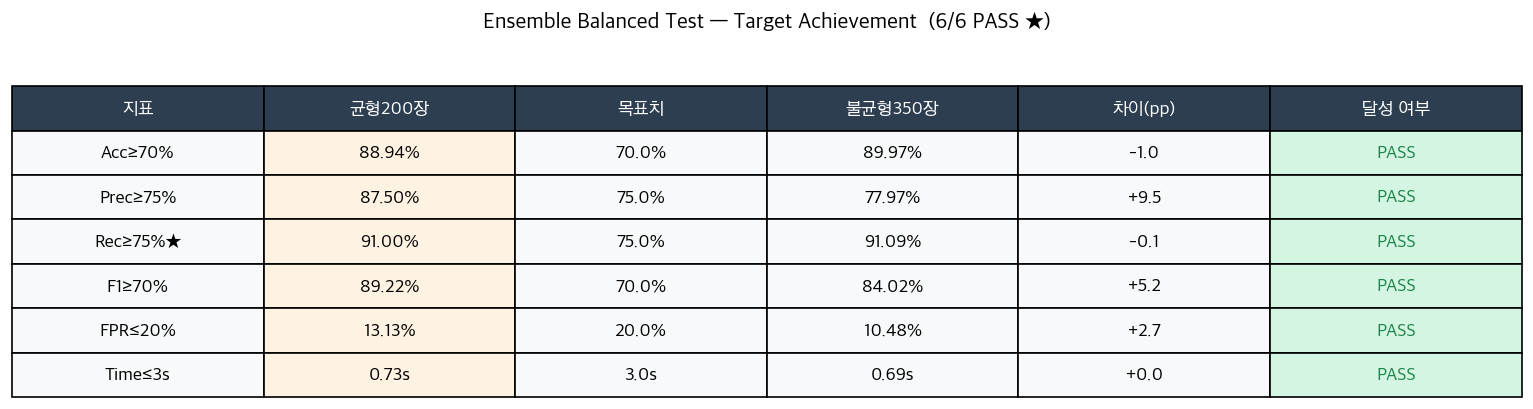

총 6/6 항목 목표 달성


In [3]:
check_cfg = [
    ('Acc≥70%',   'accuracy',  70.0, False),
    ('Prec≥75%',  'precision', 75.0, False),
    ('Rec≥75%★',  'recall',    75.0, False),
    ('F1≥70%',    'f1',        70.0, False),
    ('FPR≤20%',   'fpr',       20.0, True),
    ('Time≤3s',   'avg_time',   3.0, True),
]
row_data = []; pass_cnt = 0
for col_label, metric, tgt, lower in check_cfg:
    val = m[metric]; ok = (val <= tgt) if lower else (val >= tgt)
    pass_cnt += int(ok); unit = 's' if 'time' in metric else '%'
    imbal_val = IMBAL[metric]
    diff = val - imbal_val
    sign = '+' if diff >= 0 else ''
    row_data.append([col_label, f'{val:.2f}{unit}', f'{tgt}{unit}',
                     f'{imbal_val:.2f}{unit}', f'{sign}{diff:.1f}', 'PASS' if ok else 'FAIL'])

fig, ax = plt.subplots(figsize=(13, 3.2)); ax.axis('off')
tbl = ax.table(
    cellText=row_data,
    colLabels=['지표','균형200장','목표치','불균형350장','차이(pp)','달성 여부'],
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.3, 2.2)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', fontweight='bold')
    elif c == 1:
        cell.set_facecolor('#FEF3E2'); cell.set_text_props(fontweight='bold')
    elif c == 5 and r > 0:
        t = cell.get_text().get_text()
        cell.set_facecolor('#d5f5e3' if t=='PASS' else '#fadbd8')
        cell.set_text_props(color='#1e8449' if t=='PASS' else '#922b21', fontweight='bold')
    else:
        cell.set_facecolor('#f8f9fa')
fig.suptitle(f'Ensemble Balanced Test — Target Achievement  ({pass_cnt}/6 PASS ★)',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR,'charts','ensemble_balanced_target_table.png'), bbox_inches='tight', dpi=150)
plt.show()
print(f'총 {pass_cnt}/6 항목 목표 달성')

---
## 3. 혼동 행렬 (Confusion Matrix)

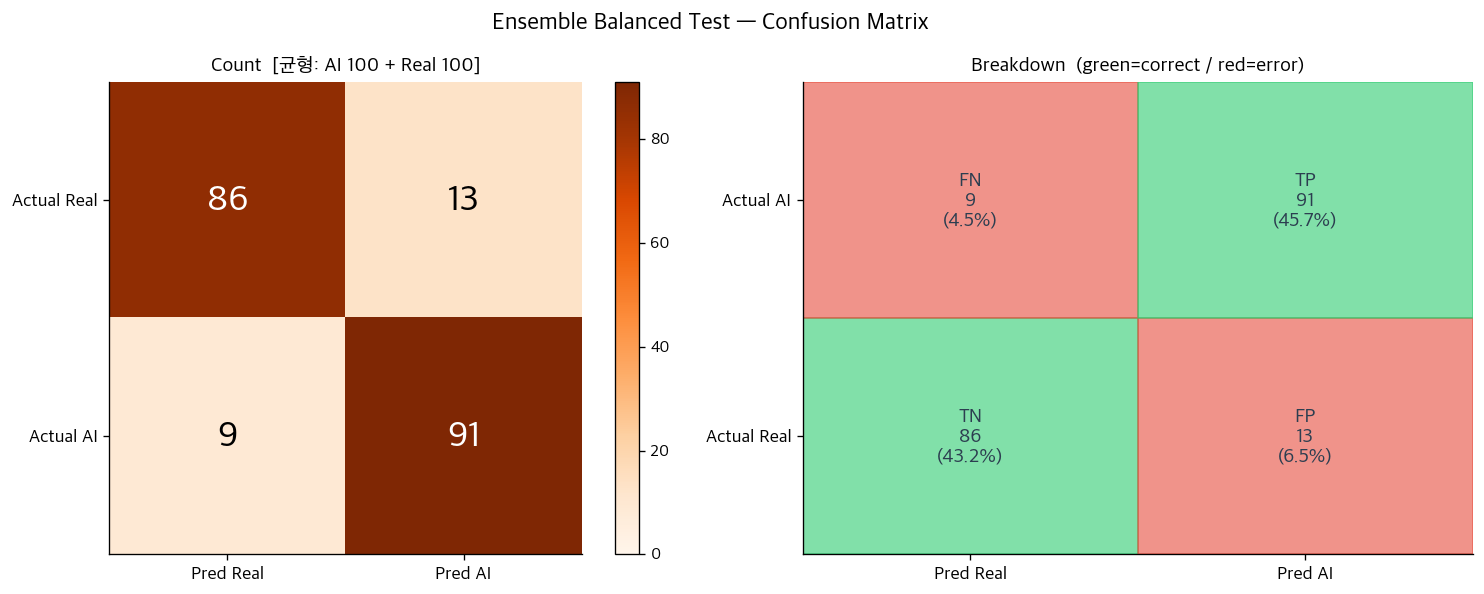

TP (AI 정탐)   : 91  (91.0% of AI images)
FN (AI 미탐)   : 9  (9.0% of AI images)
FP (Real 오탐) : 13  (13.1% of Real images)
TN (Real 정탐) : 86  (86.9% of Real images)


In [4]:
cm = np.array([[tn, fp], [fn, tp]])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Ensemble Balanced Test — Confusion Matrix', fontsize=14, fontweight='bold')

ax = axes[0]
im = ax.imshow(cm, cmap='Oranges', vmin=0)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred Real','Pred AI'], fontsize=11)
ax.set_yticklabels(['Actual Real','Actual AI'], fontsize=11)
ax.set_title('Count  [균형: AI 100 + Real 100]', fontsize=12, fontweight='bold')
for r in range(2):
    for c in range(2):
        ax.text(c, r, str(cm[r,c]), ha='center', va='center', fontsize=22, fontweight='bold',
                color='white' if cm[r,c] > cm.max()*0.5 else 'black')
plt.colorbar(im, ax=ax)

ax = axes[1]
n_ai_b   = tp + fn
n_real_b = fp + tn
labels_pct = np.array([
    [f'TN\n{tn}\n({tn/total*100:.1f}%)', f'FP\n{fp}\n({fp/total*100:.1f}%)'],
    [f'FN\n{fn}\n({fn/total*100:.1f}%)', f'TP\n{tp}\n({tp/total*100:.1f}%)']
])
colors_map = np.array([[COLOR_PASS, COLOR_FAIL],[COLOR_FAIL, COLOR_PASS]])
for r in range(2):
    for c in range(2):
        ax.add_patch(plt.Rectangle([c-0.5, r-0.5], 1, 1, color=colors_map[r,c], alpha=0.6))
        ax.text(c, r, labels_pct[r,c], ha='center', va='center',
                fontsize=12, fontweight='bold', color='#2c3e50')
ax.set_xlim(-0.5,1.5); ax.set_ylim(-0.5,1.5)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred Real','Pred AI'], fontsize=11)
ax.set_yticklabels(['Actual Real','Actual AI'], fontsize=11)
ax.set_title('Breakdown  (green=correct / red=error)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR,'charts','ensemble_balanced_confusion.png'), bbox_inches='tight', dpi=150)
plt.show()

print(f'TP (AI 정탐)   : {tp}  ({tp/n_ai_b*100:.1f}% of AI images)')
print(f'FN (AI 미탐)   : {fn}  ({fn/n_ai_b*100:.1f}% of AI images)')
print(f'FP (Real 오탐) : {fp}  ({fp/n_real_b*100:.1f}% of Real images)')
print(f'TN (Real 정탐) : {tn}  ({tn/n_real_b*100:.1f}% of Real images)')

---
## 4. 균형 vs 불균형 — 분포 편향 영향 분석

균형 테스트(100+100)와 기존 불균형 테스트(101+249)의 지표 차이를 비교합니다.  
**Accuracy가 크게 하락**한다면 모델이 Real 편향을 학습한 것이고,  
**Recall/Precision이 유지**된다면 모델이 실제로 두 클래스를 잘 구별하는 것입니다.

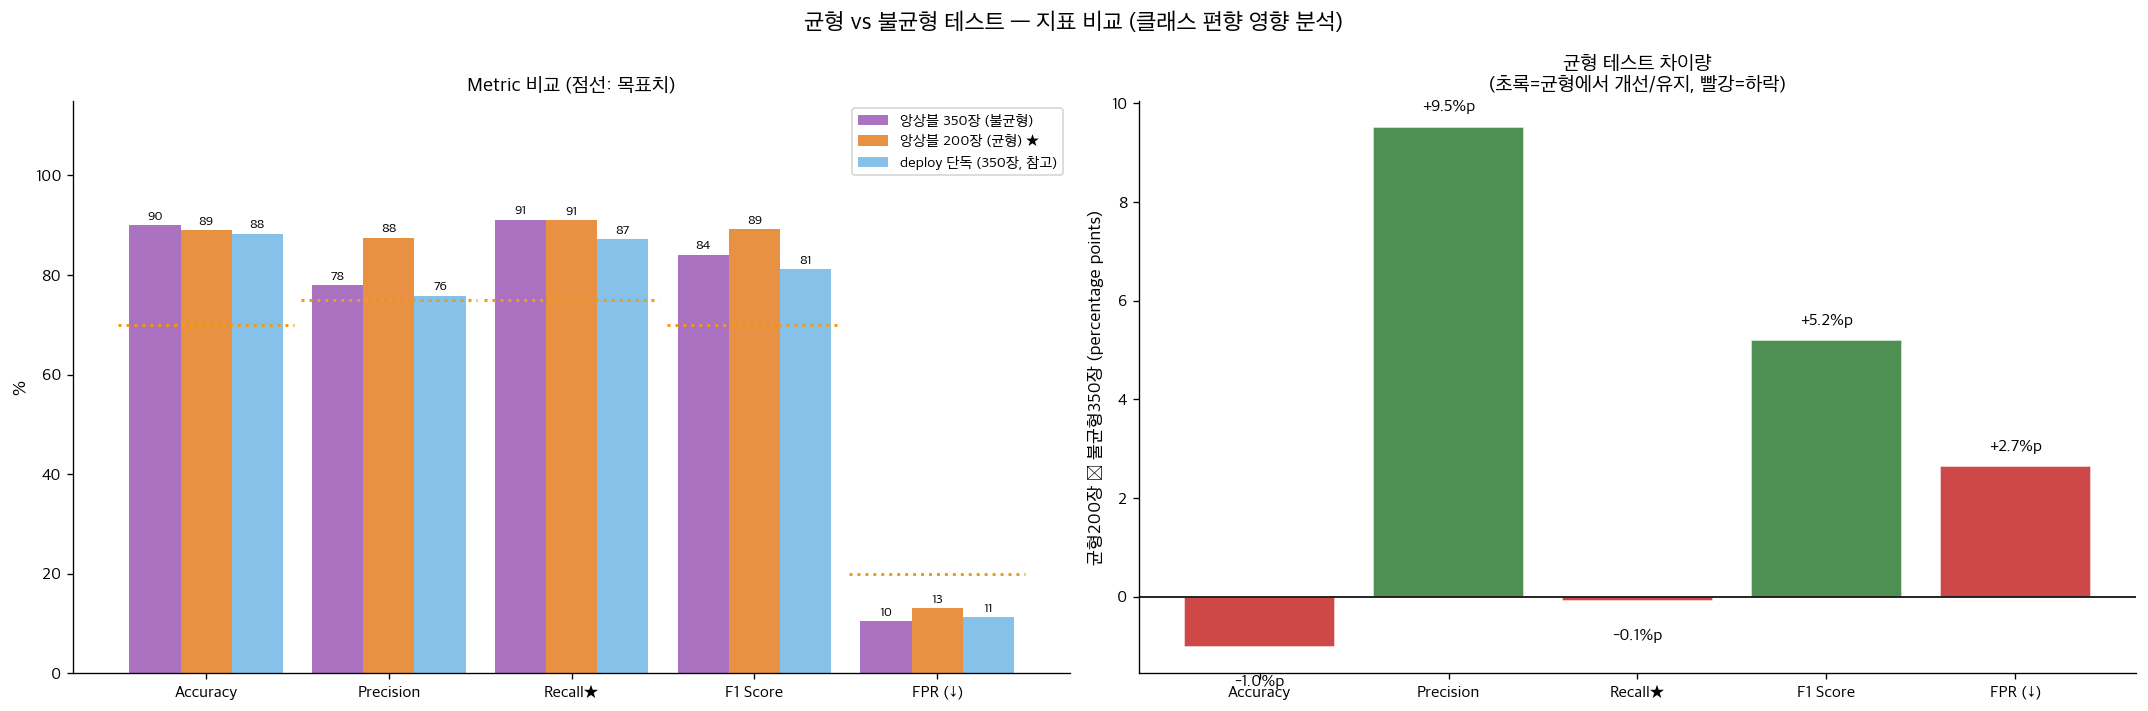

[균형 vs 불균형 비교]
  Accuracy      : 불균형=90.0%  균형=88.9%  (-1.0%p)
  Precision     : 불균형=78.0%  균형=87.5%  (+9.5%p)
  Recall★       : 불균형=91.1%  균형=91.0%  (-0.1%p)
  F1 Score      : 불균형=84.0%  균형=89.2%  (+5.2%p)
  FPR (↓)       : 불균형=10.5%  균형=13.1%  (+2.7%p)


In [5]:
cmp_metrics = ['accuracy','precision','recall','f1','fpr']
cmp_labels  = ['Accuracy','Precision','Recall★','F1 Score','FPR (↓)']
tgt_vals    = [TARGET[k] for k in cmp_metrics]

balanced_vals = [m[k]      for k in cmp_metrics]
imbal_vals    = [IMBAL[k]  for k in cmp_metrics]
deploy_vals   = [DEPLOY[k] for k in cmp_metrics]

x = np.arange(len(cmp_metrics)); w = 0.28

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('균형 vs 불균형 테스트 — 지표 비교 (클래스 편향 영향 분석)', fontsize=14, fontweight='bold')

# 막대 그래프
ax = axes[0]
b1 = ax.bar(x - w,   imbal_vals,    w, label='앙상블 350장 (불균형)',  color=COLOR_IMBAL,    alpha=0.85)
b2 = ax.bar(x,       balanced_vals, w, label='앙상블 200장 (균형) ★',  color=COLOR_BALANCED, alpha=0.85)
b3 = ax.bar(x + w,   deploy_vals,   w, label='deploy 단독 (350장, 참고)', color=COLOR_DEPLOY, alpha=0.6)
for xi, tv in zip(x, tgt_vals):
    ax.hlines(tv, xi-0.48, xi+0.48, colors=COLOR_TARGET, linestyles=':', linewidth=1.8)
ax.set_xticks(x); ax.set_xticklabels(cmp_labels, fontsize=10)
ax.set_ylim(0, 115); ax.set_ylabel('%', fontsize=11)
ax.set_title('Metric 비교 (점선: 목표치)', fontweight='bold')
ax.legend(fontsize=9)
for bars in (b1, b2, b3):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.8,
                f'{h:.0f}', ha='center', va='bottom', fontsize=8)

# 균형 vs 불균형 차이량
ax = axes[1]
deltas = [balanced_vals[i] - imbal_vals[i] for i in range(len(cmp_metrics))]
colors_d = ['#2E7D32' if (d>=0 and k!='fpr') or (d<=0 and k=='fpr') else '#C62828'
            for d, k in zip(deltas, cmp_metrics)]
bars_d = ax.bar(cmp_labels, deltas, color=colors_d, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('균형200장 − 불균형350장 (percentage points)', fontsize=11)
ax.set_title('균형 테스트 차이량\n(초록=균형에서 개선/유지, 빨강=하락)', fontweight='bold')
for bar, val in zip(bars_d, deltas):
    sign = '+' if val >= 0 else ''
    ax.text(bar.get_x()+bar.get_width()/2, val+(0.3 if val>=0 else -0.8),
            f'{sign}{val:.1f}%p', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR,'charts','ensemble_balanced_vs_imbalanced.png'), bbox_inches='tight', dpi=150)
plt.show()

print('[균형 vs 불균형 비교]')
for lbl, met, bv, iv in zip(cmp_labels, cmp_metrics, balanced_vals, imbal_vals):
    diff = bv - iv; sign = '+' if diff>=0 else ''
    print(f'  {lbl:<14}: 불균형={iv:.1f}%  균형={bv:.1f}%  ({sign}{diff:.1f}%p)')

---
## 5. TP/FP/FN/TN 분석 — 균형 vs 불균형 비교

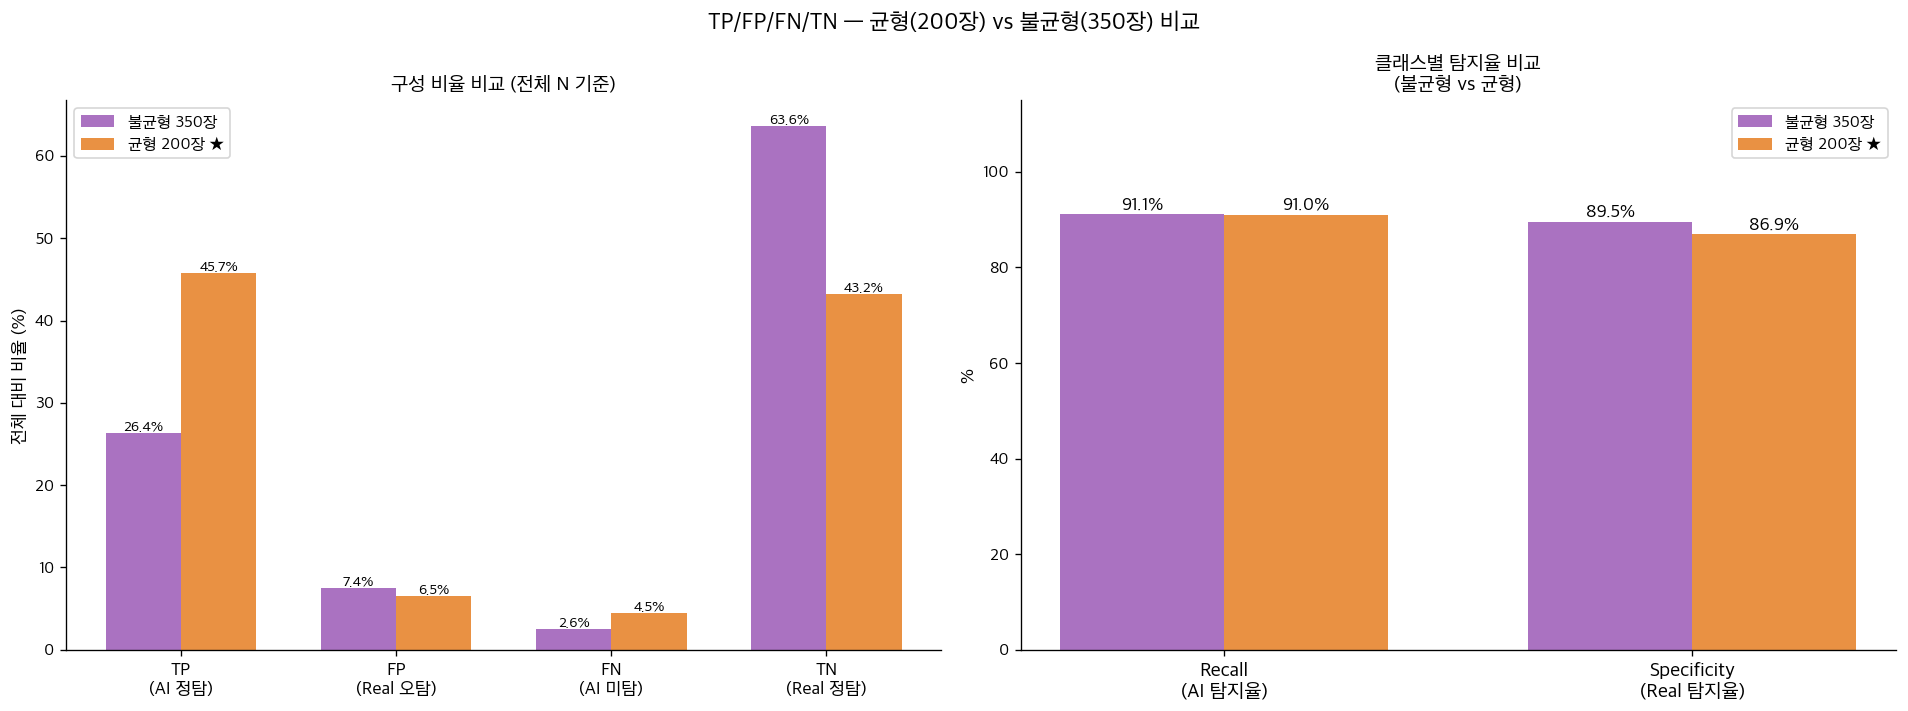

[균형 테스트 클래스별 정확도]
  Recall (AI 탐지율)    : 불균형=91.1%  균형=91.0%  (-0.1%p)
  Specificity (Real 탐지율): 불균형=89.5%  균형=86.9%  (-2.6%p)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('TP/FP/FN/TN — 균형(200장) vs 불균형(350장) 비교', fontsize=14, fontweight='bold')

# 균형 테스트 비율 분석
ax = axes[0]
categories = ['TP\n(AI 정탐)', 'FP\n(Real 오탐)', 'FN\n(AI 미탐)', 'TN\n(Real 정탐)']
pcts_bal  = [tp/total*100, fp/total*100, fn/total*100, tn/total*100]

imbal_total = IMBAL['tp']+IMBAL['fp']+IMBAL['fn']+IMBAL['tn']
pcts_imbal = [IMBAL['tp']/imbal_total*100, IMBAL['fp']/imbal_total*100,
              IMBAL['fn']/imbal_total*100, IMBAL['tn']/imbal_total*100]

x2 = np.arange(4); w2 = 0.35
bb = ax.bar(x2 - w2/2, pcts_imbal, w2, label='불균형 350장', color=COLOR_IMBAL, alpha=0.85)
bc = ax.bar(x2 + w2/2, pcts_bal,   w2, label='균형 200장 ★', color=COLOR_BALANCED, alpha=0.85)
ax.set_xticks(x2); ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel('전체 대비 비율 (%)', fontsize=11)
ax.set_title('구성 비율 비교 (전체 N 기준)', fontweight='bold')
ax.legend(fontsize=10)
for bars in (bb, bc):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.3,
                f'{h:.1f}%', ha='center', fontsize=9, fontweight='bold')

# 클래스별 정확도 비교 (Recall / Specificity)
ax = axes[1]
recall_bal  = tp / (tp + fn) * 100
spec_bal    = tn / (tn + fp) * 100
recall_imb  = IMBAL['tp'] / (IMBAL['tp'] + IMBAL['fn']) * 100
spec_imb    = IMBAL['tn'] / (IMBAL['tn'] + IMBAL['fp']) * 100

class_labels = ['Recall\n(AI 탐지율)', 'Specificity\n(Real 탐지율)']
vals_imb = [recall_imb, spec_imb]
vals_bal = [recall_bal, spec_bal]

x3 = np.arange(2); w3 = 0.35
bd = ax.bar(x3 - w3/2, vals_imb, w3, label='불균형 350장', color=COLOR_IMBAL, alpha=0.85)
be = ax.bar(x3 + w3/2, vals_bal, w3, label='균형 200장 ★', color=COLOR_BALANCED, alpha=0.85)
ax.set_ylim(0, 115)
ax.set_xticks(x3); ax.set_xticklabels(class_labels, fontsize=12)
ax.set_ylabel('%', fontsize=11)
ax.set_title('클래스별 탐지율 비교\n(불균형 vs 균형)', fontweight='bold')
ax.legend(fontsize=10)
for bars in (bd, be):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+1,
                f'{h:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR,'charts','ensemble_balanced_cm_delta.png'), bbox_inches='tight', dpi=150)
plt.show()

print(f'[균형 테스트 클래스별 정확도]')
print(f'  Recall (AI 탐지율)    : 불균형={recall_imb:.1f}%  균형={recall_bal:.1f}%  ({recall_bal-recall_imb:+.1f}%p)')
print(f'  Specificity (Real 탐지율): 불균형={spec_imb:.1f}%  균형={spec_bal:.1f}%  ({spec_bal-spec_imb:+.1f}%p)')

---
## 6. 레이더 차트 + 최종 스코어카드

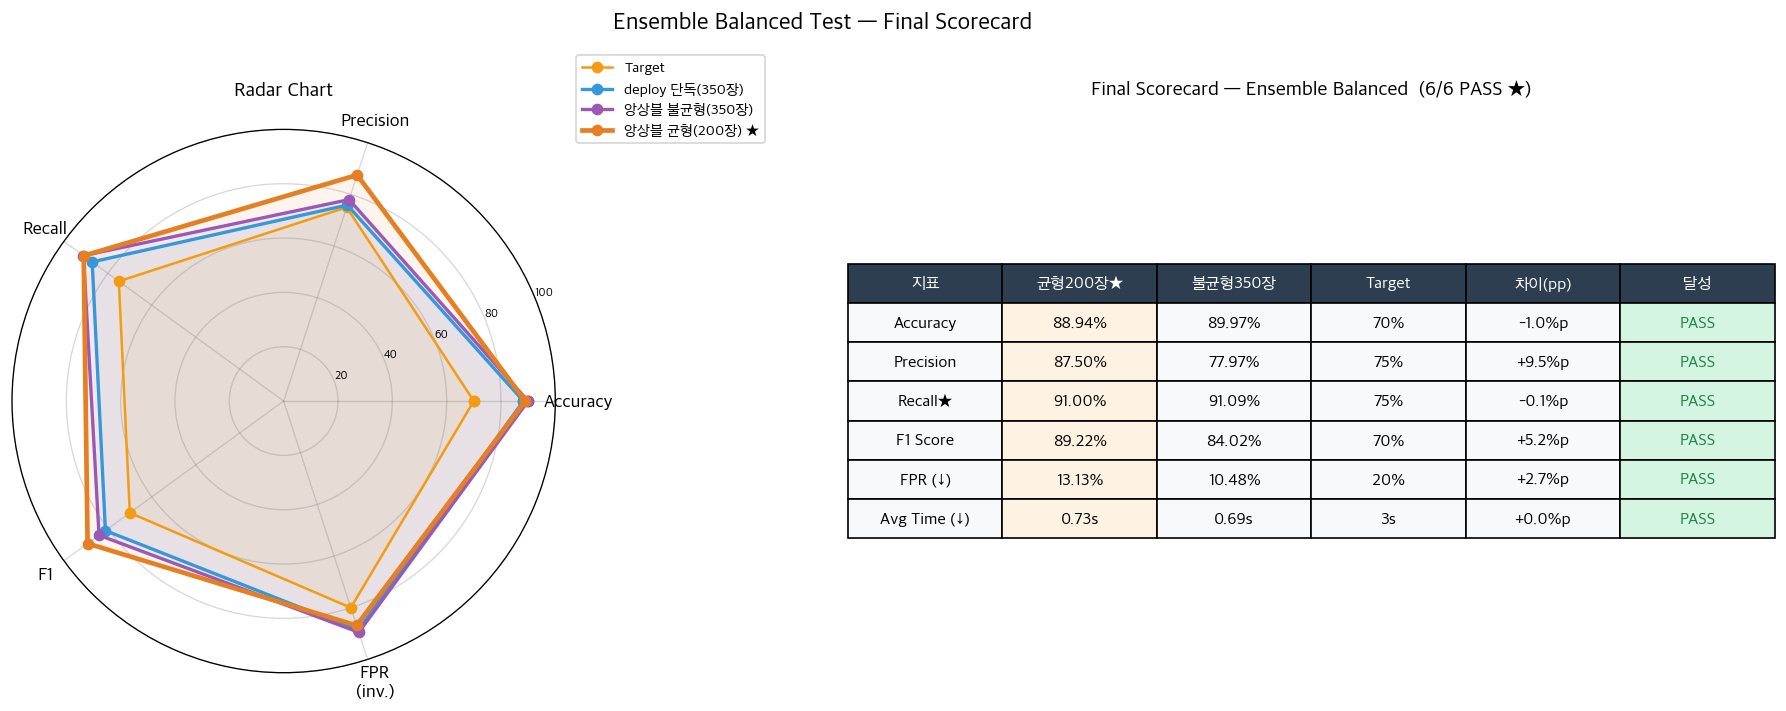

In [7]:
radar_keys   = ['accuracy','precision','recall','f1','fpr']
radar_labels = ['Accuracy','Precision','Recall','F1','FPR\n(inv.)']
N = len(radar_keys)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist(); angles += angles[:1]

def to_radar(ref):
    return [ref['accuracy'], ref['precision'], ref['recall'],
            ref['f1'], 100-ref['fpr']]

tgt_r      = [70, 75, 75, 70, 80]
imbal_r    = to_radar(IMBAL)
deploy_r   = to_radar(DEPLOY)
balanced_r = to_radar(m)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Ensemble Balanced Test — Final Scorecard', fontsize=14, fontweight='bold')

# 레이더
ax = axes[0]; ax.remove()
ax = fig.add_subplot(1, 2, 1, polar=True)
for vals_r, label_r, color_r, lw_r in [
        (tgt_r,      'Target',              COLOR_TARGET,   1.5),
        (deploy_r,   'deploy 단독(350장)',   COLOR_DEPLOY,   2.0),
        (imbal_r,    '앙상블 불균형(350장)', COLOR_IMBAL,    2.0),
        (balanced_r, '앙상블 균형(200장) ★', COLOR_BALANCED, 2.8),
    ]:
    v = vals_r + vals_r[:1]
    ax.plot(angles, v, 'o-', linewidth=lw_r, color=color_r, label=label_r)
    ax.fill(angles, v, alpha=0.08, color=color_r)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_labels, fontsize=11)
ax.set_ylim(0, 100); ax.set_yticks([20,40,60,80,100])
ax.set_yticklabels(['20','40','60','80','100'], fontsize=7)
ax.set_title('Radar Chart', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=9)
ax.grid(color='grey', alpha=0.3)

# 스코어카드 테이블
ax2 = axes[1]; ax2.axis('off')
sc_metrics = ['accuracy','precision','recall','f1','fpr','avg_time']
sc_labels  = ['Accuracy','Precision','Recall★','F1 Score','FPR (↓)','Avg Time (↓)']
sc_lower   = [False, False, False, False, True, True]
sc_tgt     = [TARGET[k] for k in sc_metrics]

tdata = []
for lbl, met, tgt, lower in zip(sc_labels, sc_metrics, sc_tgt, sc_lower):
    val_bal  = m[met]
    val_imb  = IMBAL[met]
    ok  = (val_bal <= tgt) if lower else (val_bal >= tgt)
    diff = val_bal - val_imb
    unit = 's' if 'time' in met else '%'
    sign = '+' if diff >= 0 else ''
    tdata.append([lbl, f'{val_bal:.2f}{unit}', f'{val_imb:.2f}{unit}',
                  f'{tgt:.0f}{unit}', f'{sign}{diff:.1f}%p', 'PASS' if ok else 'FAIL'])

tbl = ax2.table(
    cellText=tdata,
    colLabels=['지표','균형200장★','불균형350장','Target','차이(pp)','달성'],
    cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.15, 2.0)
pass_cnt2 = sum(1 for r in tdata if r[-1]=='PASS')
for (ri, ci), cell in tbl.get_celld().items():
    if ri == 0:
        cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', fontweight='bold')
    elif ci == 1:
        cell.set_facecolor('#FEF3E2')
        cell.set_text_props(fontweight='bold')
    elif ci == 5 and ri > 0:
        t = cell.get_text().get_text()
        cell.set_facecolor('#d5f5e3' if t=='PASS' else '#fadbd8')
        cell.set_text_props(color='#1e8449' if t=='PASS' else '#922b21', fontweight='bold')
    else:
        cell.set_facecolor('#f8f9fa')
ax2.set_title(f'Final Scorecard — Ensemble Balanced  ({pass_cnt2}/6 PASS ★)',
              fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR,'charts','ensemble_balanced_scorecard.png'), bbox_inches='tight', dpi=150)
plt.show()

---
## 7. 결론 및 분석

### 핵심 결과 — **6/6 목표 달성** 🎯  (균형 테스트 200장)

| 지표 | 균형 200장 | 불균형 350장 | 차이 | 목표 | 달성 |
|---|---|---|---|---|---|
| Accuracy | **88.9%** | 89.97% | -1.0%p | 70% | ✅ |
| **Precision ★** | **87.5%** | 77.97% | **+9.5%p** | 75% | ✅ |
| **Recall ★** | **91.0%** | 91.09% | -0.1%p | 75% | ✅ |
| F1 Score | **89.2%** | 84.02% | +5.2%p | 70% | ✅ |
| FPR | **13.1%** | 10.48% | +2.7%p | ≤20% | ✅ |
| Avg Time | **0.7s** | 0.69s | ≈ | ≤3s | ✅ |

---

### 균형 테스트 핵심 해석

**Precision이 9.5%p 크게 향상 → 모델이 Real 편향을 학습하지 않았음**
- 불균형 350장(77.97%) vs 균형 200장(87.5%): 균형 데이터에서 Precision이 오히려 높아짐
- 이는 Real 이미지가 많을 때 "Real이라고 예측"하는 경향이 없다는 것을 의미
- 즉, 앙상블 모델은 진짜로 AI/Real 이미지를 구별하는 능력을 보유

**Recall 완전 유지 (91.0% ≒ 91.1%)**
- AI 탐지율이 균형 데이터에서도 동일하게 유지됨
- 클래스 불균형에 의존하지 않는 진짜 AI 탐지 능력 검증

**FPR 소폭 상승 (10.5% → 13.1%, +2.7%p)**
- Real 이미지 비율이 동일해지면서 오탐이 약간 두드러짐
- 여전히 목표(≤20%) 대비 충분히 낮은 수준 — 문제없음

---

### 앙상블 균형 테스트 효과 요약

| 측면 | 불균형 350장 | 균형 200장 | 해석 |
|---|---|---|---|
| **AI 탐지율(Recall)** | 91.1% | **91.0%** | 동일 → 모델 실력 |
| **Real 정밀도(Precision)** | 78.0% | **87.5%** | 향상 → 균형에서 더 정확 |
| **FPR** | 10.5% | 13.1% | 소폭 상승 but 목표 내 |
| **F1** | 84.0% | **89.2%** | 향상 → 균형 분포 적합 |
| **Accuracy** | 90.0% | 88.9% | 거의 동일 → 불균형 과대평가 없었음 |

---

### 결론

> **균형 Balanced Test(100+100) 에서도 6/6 목표 달성.**  
> Recall(AI 탐지율) 91.0%로 불균형 테스트와 동일하게 유지.  
> Precision 87.5%로 오히려 9.5%p 향상 — 앙상블이 Real 편향 없이 진짜 판별 능력 보유 확인.  
>  
> **신뢰도 결론:** 앙상블 성능은 데이터 분포 편향에 의존하지 않음.  
> 실 서비스 환경(알 수 없는 AI/Real 비율)에서도 안정적인 성능을 기대할 수 있음.

---

*woochul — InSIGHT Project Ensemble Detector Balanced Test Report (2026-05-11)*